# 02. Boosting 모델 학습

학습 기간 유연 설정 (PERIOD_MODE 사용)

In [177]:
import pandas as pd, numpy as np, warnings
import xgboost as xgb, lightgbm as lgb, optuna
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostRegressor,CatBoostClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter
import sklearn.preprocessing
import pickle

smote = SMOTE(random_state=42)
warnings.filterwarnings("ignore")
# ════════════════════════════════════════════════
# ✏️  학습 기간 설정 (세 가지 방식 중 하나만 선택)
# ════════════════════════════════════════════════

PERIOD_MODE = "from"       # "range"   : 특정 구간만 학습
                            # "exclude" : 특정 구간을 제외하고 학습
                            # "from"    : 특정 연도 이후만 학습 (기존 방식)

PERIOD_START = 2020         # 구간 시작 연도 (range / exclude 공통)
PERIOD_END   = 2021       # 구간 종료 연도 (range / exclude 공통)
MIN_YEAR     = 2016         # "from" 모드일 때만 사용
# ════════════════════════════════════════════════

# 설정
FEATURE_VERSION = "v2"
SPLIT_STRATEGY = "year"
TARGET_TYPE = "classification" # regression , classification
TEST_SIZE = 0.2
RANDOM_STATE = 42
ENABLE_TUNING = True
N_TRIALS = 50
CV_FOLDS = 5
print(f"✅ 설정 완료: {FEATURE_VERSION}, PERIOD_MODE = {PERIOD_MODE}, PERIOD_START = {PERIOD_START}, PERIOD_END = {PERIOD_END} ,MIN_YEAR = {MIN_YEAR}")

✅ 설정 완료: v2, PERIOD_MODE = from, PERIOD_START = 2020, PERIOD_END = 2021 ,MIN_YEAR = 2016


In [178]:
# 데이터 로드
df = pd.read_csv(f"data/processed/feature_table_{FEATURE_VERSION}.csv", encoding="utf-8-sig")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2454 entries, 0 to 2453
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   movie_id                 2454 non-null   str    
 1   title                    2454 non-null   str    
 2   runtime                  2454 non-null   float64
 3   rating_encoded           2454 non-null   float64
 4   is_korean                2454 non-null   float64
 5   genre                    2454 non-null   str    
 6   open_date                2454 non-null   str    
 7   open_month               2454 non-null   float64
 8   open_day_of_week         2454 non-null   float64
 9   is_summer                2454 non-null   int64  
 10  is_winter                2454 non-null   int64  
 11  is_holiday_release       2454 non-null   int64  
 12  holiday_nearby_count     2454 non-null   int64  
 13  director_avg_audi        2454 non-null   float64
 14  director_movie_count     2454 non-n

In [179]:
# 데이터 로드
df = pd.read_csv(f"data/processed/feature_table_{FEATURE_VERSION}.csv", encoding="utf-8-sig")

# open_date를 datetime으로 변환 (결측치 처리)
df["open_date"] = pd.to_datetime(df["open_date"], errors="coerce")

# open_year 추출
df["open_year"] = df["open_date"].dt.year.astype("Int64")  # NaT 허용하는 정수형

# 코로나 기간 제외
# df = (
#     df[~df['open_year'].isin([2020, 2021])]
#     .reset_index(drop=True)
# )

# 검증
print(f"✅ {FEATURE_VERSION} 로드: {df.shape[0]:,}편")
print(f"   개봉 년도: {int(df['open_year'].min())}~{int(df['open_year'].max())}")
print(f"   open_date 결측치: {df['open_date'].isna().sum()}건")

✅ v2 로드: 2,454편
   개봉 년도: 2016~2025
   open_date 결측치: 0건


In [180]:
# PERIOD_MODE에 따라 학습 데이터 필터링

if PERIOD_MODE == "range":
    # 특정 구간만 학습 (예: 2012~2020)
    mask = (df["open_year"] >= PERIOD_START) & (df["open_year"] <= PERIOD_END)
    desc = f"{PERIOD_START}~{PERIOD_END}년"

elif PERIOD_MODE == "exclude":
    # 특정 구간 제외 (예: 코로나 2020~2021 제외)
    mask = ~((df["open_year"] >= PERIOD_START) & (df["open_year"] <= PERIOD_END))
    desc = f"{PERIOD_START}~{PERIOD_END}년 제외"

elif PERIOD_MODE == "from":
    # 특정 연도 이후만 (기존 방식)
    mask = df["open_year"] >= MIN_YEAR
    desc = f"{MIN_YEAR}년 이후"


print(f"📅 학습 기간 모드  : {PERIOD_MODE} ({desc})")


📅 학습 기간 모드  : from (2016년 이후)


In [181]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2454 entries, 0 to 2453
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   movie_id                 2454 non-null   str           
 1   title                    2454 non-null   str           
 2   runtime                  2454 non-null   float64       
 3   rating_encoded           2454 non-null   float64       
 4   is_korean                2454 non-null   float64       
 5   genre                    2454 non-null   str           
 6   open_date                2454 non-null   datetime64[us]
 7   open_month               2454 non-null   float64       
 8   open_day_of_week         2454 non-null   float64       
 9   is_summer                2454 non-null   int64         
 10  is_winter                2454 non-null   int64         
 11  is_holiday_release       2454 non-null   int64         
 12  holiday_nearby_count     2454 non-null   int6

In [182]:
# hit_class 재구성,(기본 0,1,2,3[0~100,100~300,300~500,500~])
REMAP = {0: 0, 1: 1, 2: 1, 3: 1}  # 100만 미만=0, 이상=1
df['hit_class'] = df['hit_class'].map(REMAP).astype('Int64')

print(df['hit_class'].value_counts().sort_index())
# 예상: 0 → 2121편 / 1 → 333편  (약 6.4:1)

hit_class
0    2121
1     333
Name: count, dtype: Int64


In [183]:
# 피처 준비
df_train = df[mask].copy()
target_col = "log_audience" if TARGET_TYPE == "regression" else "hit_class"
y = df_train[target_col].copy()
exclude_cols = ["movie_id", "title", "total_audience", "log_audience", "hit_class", "open_date", "open_year"]
feature_cols = [c for c in df_train.columns if c not in exclude_cols]
X = df_train[feature_cols].copy()

# 범주형 인코딩
for col in X.select_dtypes(include=["object"]).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))
print(f"피처: {len(feature_cols)}, 샘플: {len(y):,}")
print(f"   전체 데이터     : {len(df):,}편")
print(f"   학습 데이터     : {len(df_train):,}편")
print(f"   제외 데이터     : {len(df) - len(df_train):,}편")
print(f"   개봉 년도 범위  : {int(df_train['open_year'].min())}~{int(df_train['open_year'].max())}")

피처: 28, 샘플: 2,454
   전체 데이터     : 2,454편
   학습 데이터     : 2,454편
   제외 데이터     : 0편
   개봉 년도 범위  : 2016~2025


In [184]:
# Train/Test 분할
if SPLIT_STRATEGY == "year":
    sorted_idx = df_train.sort_values("open_year").index
    split_idx = int(len(sorted_idx) * (1 - TEST_SIZE))
    train_idx, test_idx = sorted_idx[:split_idx], sorted_idx[split_idx:]
    X_train, X_test = X.loc[train_idx], X.loc[test_idx]
    y_train, y_test = y.loc[train_idx], y.loc[test_idx]
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,test_size=TEST_SIZE, random_state=RANDOM_STATE)
print(f"Train: {len(X_train):,}, Test: {len(X_test):,}")

Train: 1,963, Test: 491


In [185]:
counter = Counter(y_train)
neg, pos = counter[0], counter[1]

print(f'class 0 (일반): {neg}, class 1 (흥행): {pos}')
print(f'scale_pos_weight: {scale:.2f}')

class 0 (일반): 1681, class 1 (흥행): 282
scale_pos_weight: 5.96


In [186]:
# smote 적용
smote = SMOTE(random_state=42)

In [187]:
# XGBoost
if TARGET_TYPE == "regression":
    xgb_model = xgb.XGBRegressor(max_depth=6, learning_rate=0.1, n_estimators=100, random_state=RANDOM_STATE, verbosity=0,class_weight='balanced')
    xgb_model.fit(X_train, y_train)
    y_pred = xgb_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"✅ XGBoost: RMSE={rmse:.4f}, R²={r2:.4f}")
else:
    scale = neg / pos  # XGB용
    X_train_resampled, y_train_resampled = smote.fit_resample(
        X_train,
        y_train
    )
    xgb_model = xgb.XGBClassifier(objective="multi:softmax", num_class=4, max_depth=6, learning_rate=0.1, n_estimators=100, random_state=RANDOM_STATE, verbosity=0,class_weight='balanced',scale_pos_weight=scale,eval_metric='logloss')
    xgb_model.fit(X_train_resampled, y_train_resampled)
    y_pred = xgb_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ XGBoost: Accuracy={acc:.4f}")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print(classification_report(y_test, y_pred))

✅ XGBoost: Accuracy=0.9226
[[425  15]
 [ 23  28]]
              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96       440
         1.0       0.65      0.55      0.60        51

    accuracy                           0.92       491
   macro avg       0.80      0.76      0.78       491
weighted avg       0.92      0.92      0.92       491



In [197]:
# LightGBM
if TARGET_TYPE == "regression":
    lgb_model = lgb.LGBMRegressor(max_depth=6, learning_rate=0.1, n_estimators=100, random_state=RANDOM_STATE, verbose=-1)
    lgb_model.fit(X_train, y_train)
    y_pred = lgb_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"✅ LightGBM: RMSE={rmse:.4f}, R²={r2:.4f}")
else:
    X_train_resampled, y_train_resampled = smote.fit_resample(
        X_train,
        y_train
    )
    lgb_model = lgb.LGBMClassifier(objective="multiclass", num_class=4, max_depth=6, learning_rate=0.1, n_estimators=100, class_weight='balanced',random_state=RANDOM_STATE, verbose=-1)
    lgb_model.fit(X_train_resampled, y_train_resampled)
    y_pred = lgb_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ LightGBM: Accuracy={acc:.4f}")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print(classification_report(y_test, y_pred))

✅ LightGBM: Accuracy=0.9185
[[428  12]
 [ 28  23]]
              precision    recall  f1-score   support

         0.0       0.94      0.97      0.96       440
         1.0       0.66      0.45      0.53        51

    accuracy                           0.92       491
   macro avg       0.80      0.71      0.75       491
weighted avg       0.91      0.92      0.91       491



In [199]:
# Catboost
if TARGET_TYPE == "regression":
    cb_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    eval_metric='R2',
    verbose=100
)
    cb_model.fit(X_train, y_train)
    y_pred = cb_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"✅ Catboost: RMSE={rmse:.4f}, R²={r2:.4f}")
else:
    X_train_resampled, y_train_resampled = smote.fit_resample(
        X_train,
        y_train
    )
    cb_model = CatBoostClassifier(
    loss_function='Logloss',   # 이진분류
    eval_metric='F1',          # 불균형 데이터니까 F1 권장
    depth=6,
    learning_rate=0.03,
    iterations=2000,
    l2_leaf_reg=5,
    random_state=42,
    verbose=0,
    class_weights=[1, scale]
    )
    cb_model.fit(X_train_resampled, y_train_resampled)
    y_pred = cb_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ Catboost: Accuracy={acc:.4f}")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print(classification_report(y_test, y_pred))

✅ Catboost: Accuracy=0.9043
[[413  27]
 [ 20  31]]
              precision    recall  f1-score   support

         0.0       0.95      0.94      0.95       440
         1.0       0.53      0.61      0.57        51

    accuracy                           0.90       491
   macro avg       0.74      0.77      0.76       491
weighted avg       0.91      0.90      0.91       491



# Feature Correlation / Importance 분석 셀

## 1. log_audience와 상관계수 높은 feature 출력

In [190]:
# Boosting 학습 파일에 추가할 Feature Correlation / Importance 분석 셀
import matplotlib.pyplot as plt
import seaborn as sns

# 분석 대상 컬럼
exclude_cols = [
    'movie_id',
    'title',
    'genre',
    'open_date',
    'total_audience',
    'hit_class'
]

numeric_cols = [
    col for col in df.columns
    if col not in exclude_cols
]

# 상관계수 계산
corr_series = (
    df[numeric_cols]
    .corr()['log_audience']
    .drop('log_audience')
    .sort_values(key=abs, ascending=False)
)

print('=' * 60)
print(f'{FEATURE_VERSION} log_audience 와의 상관계수 TOP 15')
print('=' * 60)
print(corr_series.head(15))

v2 log_audience 와의 상관계수 TOP 15
distributor_avg_audi     0.489029
trend_pre7_avg           0.470247
relative_search_share    0.425951
cast_max_star_power      0.400497
trend_pre7_max           0.350843
lead_actor_avg_audi      0.312459
runtime                  0.294427
market_avg_audi_7d       0.285093
is_covid_period         -0.281319
director_avg_audi        0.276213
same_week_releases      -0.233976
producer_avg_audi        0.190798
open_day_of_week        -0.189850
open_year               -0.183554
producer_movie_count     0.174110
Name: log_audience, dtype: float64


## 2. 상관계수 시각화

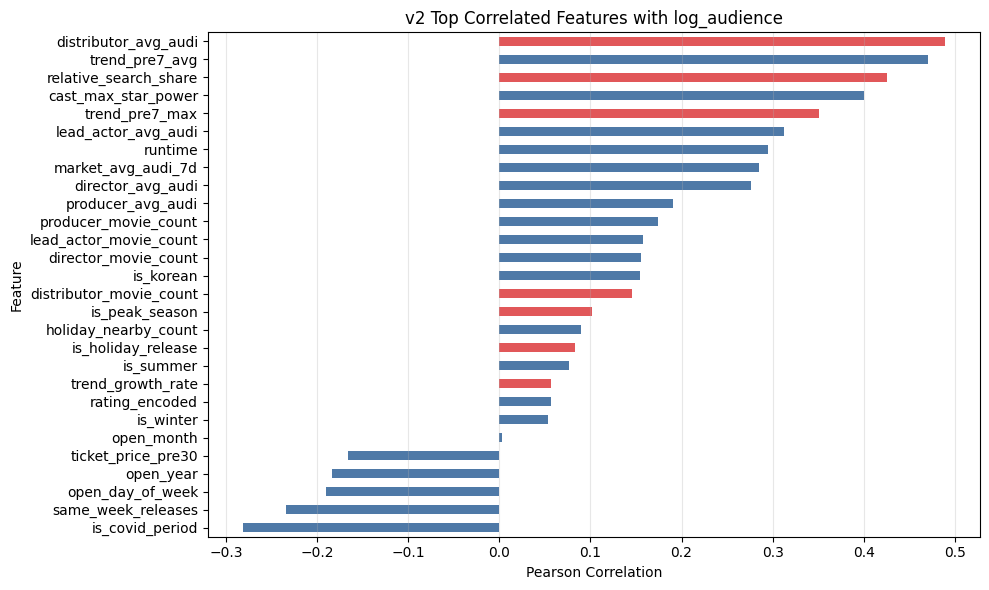

In [191]:
plt.figure(figsize=(10, 6))

colors = [
    '#4e79a7' if v > 0 else '#e15759'
    for v in corr_series.head(15).values
]

corr_series.head(30).sort_values().plot(
    kind='barh',
    color=colors
)

plt.title(f'{FEATURE_VERSION} Top Correlated Features with log_audience')
plt.xlabel('Pearson Correlation')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 전체 Feature Heatmap

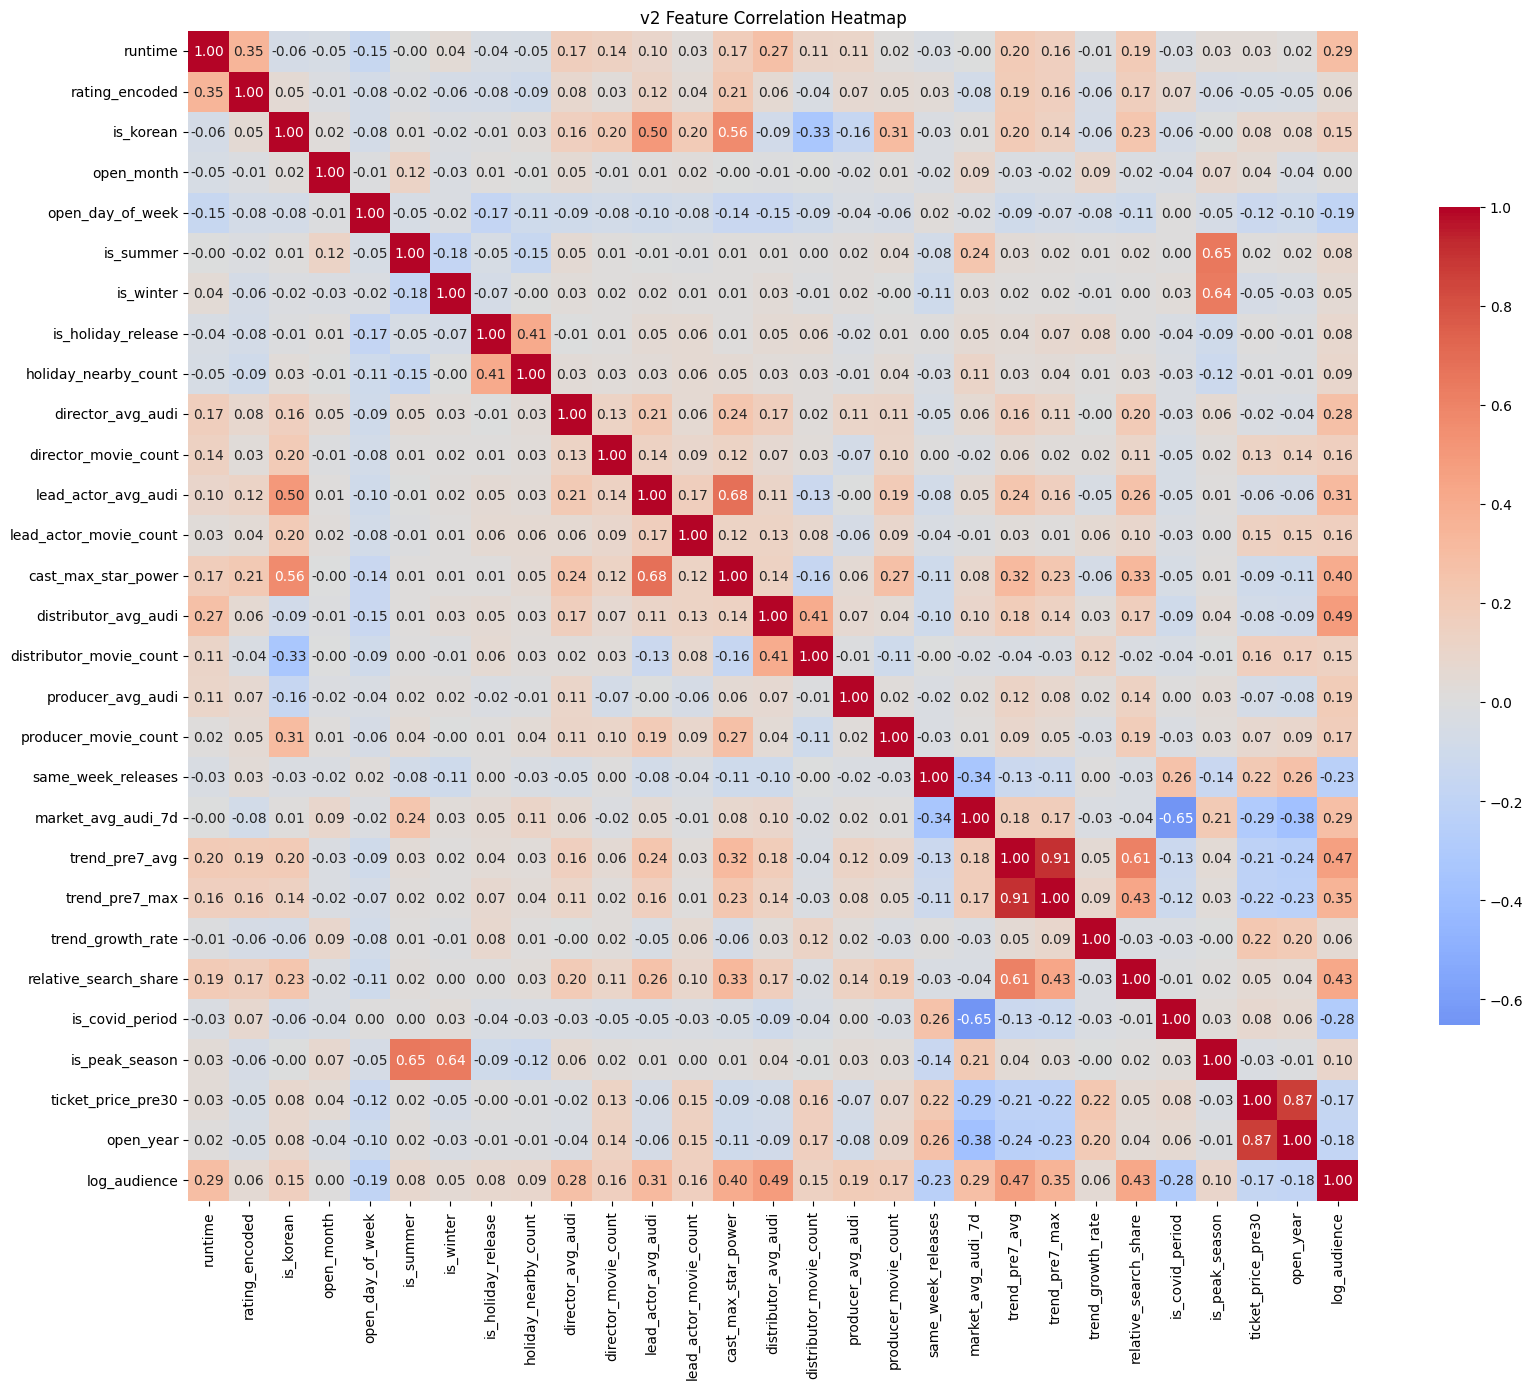

In [192]:
# =====================================================
# Feature Heatmap
# =====================================================

heatmap_cols = [
    col for col in numeric_cols
    if col != 'log_audience'
]

corr_matrix = df[
    heatmap_cols + ['log_audience']
].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    square=True,
    cbar_kws={'shrink': 0.7}
)

plt.title(f'{FEATURE_VERSION} Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. CatBoost Feature Importance 시각화

In [193]:
# =====================================================
# CatBoost Feature Importance
# =====================================================

feature_names = X.columns

cat_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': cb_model.feature_importances_
})

cat_importance = (
    cat_importance
    .sort_values('importance', ascending=False)
)
cat_importance=cat_importance.reset_index()
print('=' * 60)
print(f'{FEATURE_VERSION} CatBoost Feature Importance TOP 20')
print('=' * 60)

display(cat_importance.head(20))

v2 CatBoost Feature Importance TOP 20


,index,feature,importance
0,1,rating_encoded,13.885663
1,21,trend_pre7_avg,9.439794
2,15,distributor_avg_audi,6.870560
3,22,trend_pre7_max,6.751260
4,5,open_day_of_week,5.840826
5,10,director_avg_audi,5.370044
6,24,relative_search_share,5.288900
7,23,trend_growth_rate,5.260461
8,3,genre,4.943538
9,0,runtime,4.759222


## 5. Feature Importance 시각화

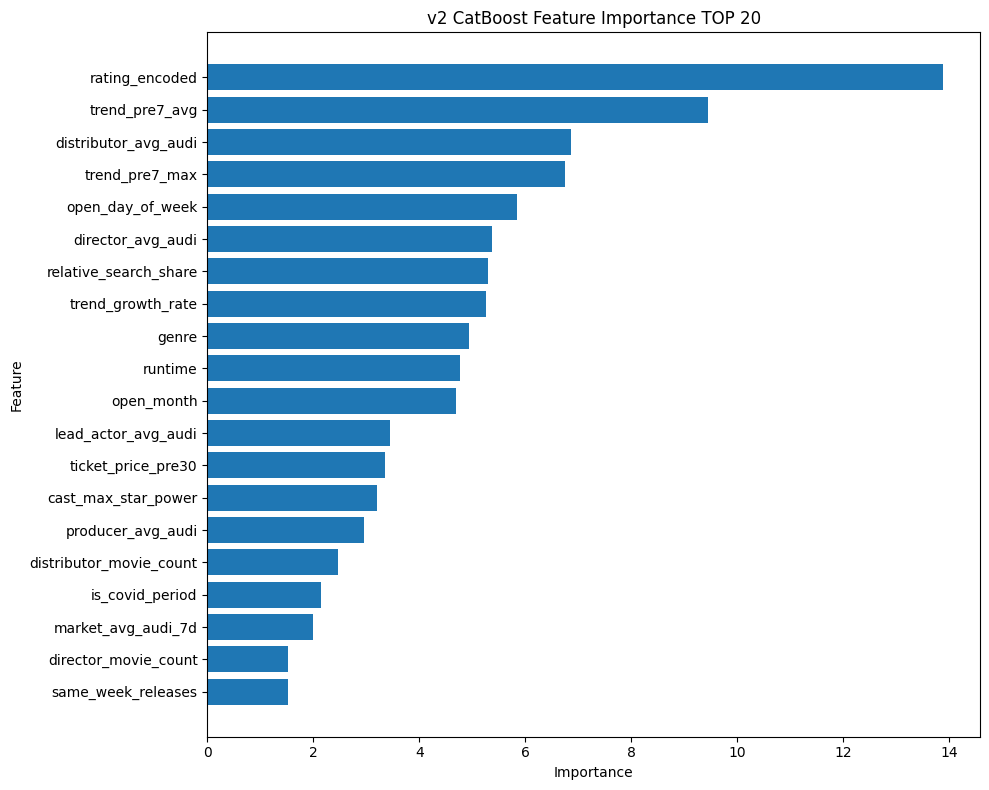

In [194]:
plt.figure(figsize=(10, 8))

plot_df = cat_importance.head(20).sort_values('importance')

plt.barh(
    plot_df['feature'],
    plot_df['importance']
)

plt.title(f'{FEATURE_VERSION} CatBoost Feature Importance TOP 20')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [195]:
# 모드별 파일명 자동 생성
period_tag = {
    "range"  : f"{PERIOD_START}_{PERIOD_END}",
    "exclude": f"ex{PERIOD_START}_{PERIOD_END}",
    "from"   : f"from{MIN_YEAR}",
}[PERIOD_MODE]

model_prefix = f"{FEATURE_VERSION}_{period_tag}"

with open(f"models/{model_prefix}_xgboost.pkl", "wb") as f:
    pickle.dump(xgb_model, f)
with open(f"models/{model_prefix}_lightgbm.pkl", "wb") as f:
    pickle.dump(lgb_model, f)
with open(f"models/{model_prefix}_catboost.pkl", "wb") as f:
    pickle.dump(cb_model, f)

print(f"✅ 모델 저장 완료: models/{model_prefix}_*.pkl")

✅ 모델 저장 완료: models/v2_from2016_*.pkl


In [196]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2454 entries, 0 to 2453
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   movie_id                 2454 non-null   str           
 1   title                    2454 non-null   str           
 2   runtime                  2454 non-null   float64       
 3   rating_encoded           2454 non-null   float64       
 4   is_korean                2454 non-null   float64       
 5   genre                    2454 non-null   str           
 6   open_date                2454 non-null   datetime64[us]
 7   open_month               2454 non-null   float64       
 8   open_day_of_week         2454 non-null   float64       
 9   is_summer                2454 non-null   int64         
 10  is_winter                2454 non-null   int64         
 11  is_holiday_release       2454 non-null   int64         
 12  holiday_nearby_count     2454 non-null   int6